# Instructions

- All code must be contained in this notebook. No separate code files.
- The code must compile and run without errors.
- Submit as `[your_name].ipynb` with a separate `[your_name]_requirements.txt` file.
- Be prepared to discuss your design decisions in the technical interview.

# Describe the environment that have been used to complete the task
- Python version: __
- GPU used for training (if any): __
- CPU used for inference timing: __

# Imports, Functions, Global Variables, Classes
Define all shared code in the cell below.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from nats_bench import create
from xautodl.models import get_cell_based_tiny_net
from types import SimpleNamespace
import os
import onnxruntime
import numpy as np
from onnxruntime.quantization import quantize_static, CalibrationDataReader, QuantType
import onnx
import matplotlib.pyplot as plt

# Set the TORCH_HOME environment variable for NATS-Bench files
os.environ['TORCH_HOME'] = "./.torch/"

INDEX = 5338          # NATS-Bench architecture index
EPOCHS = 90
BATCH_SIZE = 512
LR = 0.1
MOMENTUM = 0.9
WEIGHT_DECAY = 5e-4
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

ONNX_PATH = "model_" + str(INDEX) + ".onnx"

# NATS-Bench models return tuple where the first element is the output and the second element is a dictionary of additional information
def inference(model, x):
    out = model(x)
    return out[0] if isinstance(out, tuple) else out

In [81]:
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

2.5.1+cu121
True
NVIDIA GeForce RTX 3050 Laptop GPU


# 2.1 Design of a Compact CNN

**Requirements:**
- Model size: < 500 KB (FP32)
- Target test accuracy: ≥ 85%

In [95]:
# Your code goes here
api = create(None, 'sss', fast_mode=True, verbose=False)

config = api.get_net_config(INDEX, 'cifar10')
config = SimpleNamespace(**config)

model = get_cell_based_tiny_net(config).to(DEVICE)

# -----------------------
# CIFAR10 DATA (same normalization as NATS-Bench)
# -----------------------
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),
        (0.2023, 0.1994, 0.2010)
    ),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),
        (0.2023, 0.1994, 0.2010)
    ),
])

trainset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform_train
)

trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2
)

testset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform_test
)

testloader = torch.utils.data.DataLoader(
    testset, batch_size=256, shuffle=False, num_workers=2
)

# -----------------------
# LOSS / OPTIMIZER
# -----------------------
criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(
    model.parameters(),
    lr=LR,
    momentum=MOMENTUM,
    weight_decay=WEIGHT_DECAY,
    nesterov=True
)

# NATS-Bench uses cosine decay
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS
)

[2026-02-21 18:12:18] Try to use the default NATS-Bench (size) path from fast_mode=True and path=None.
Files already downloaded and verified
Files already downloaded and verified


In [96]:
# ---- add before training ----
loss_log = []

# -----------------------
# TRAIN LOOP
# -----------------------
for epoch in range(EPOCHS):

    model.train()
    total_loss = 0
    batches = 0

    for inputs, labels in trainloader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = inference(model, inputs)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        batches += 1

    scheduler.step()

    # ---- compute average loss + log ----
    avg_loss = total_loss / batches
    loss_log.append(avg_loss)

    # ---- evaluation ----
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = inference(model, inputs)
            _, pred = outputs.max(1)
            total += labels.size(0)
            correct += pred.eq(labels).sum().item()

    acc = 100 * correct / total
    if((epoch + 1) % 5 == 0):
        print(f"Epoch {epoch+1:3d} | loss {avg_loss:.4f} | test acc {acc:.2f}%")

    torch.save(model, "model.pt")
    torch.save(model.state_dict(), "model_state_dict.pt")

print("Saved to model.pt")

Epoch   5 | loss 0.6800 | test acc 72.47%
Epoch  10 | loss 0.5062 | test acc 77.03%
Epoch  15 | loss 0.4394 | test acc 80.04%
Epoch  20 | loss 0.4048 | test acc 80.95%
Epoch  25 | loss 0.3723 | test acc 80.34%
Epoch  30 | loss 0.3523 | test acc 79.02%
Epoch  35 | loss 0.3329 | test acc 81.87%
Epoch  40 | loss 0.3155 | test acc 79.63%
Epoch  45 | loss 0.2973 | test acc 81.56%
Epoch  50 | loss 0.2780 | test acc 84.05%
Epoch  55 | loss 0.2583 | test acc 85.53%
Epoch  60 | loss 0.2413 | test acc 83.89%
Epoch  65 | loss 0.2169 | test acc 86.04%
Epoch  70 | loss 0.1951 | test acc 86.18%
Epoch  75 | loss 0.1704 | test acc 87.92%
Epoch  80 | loss 0.1480 | test acc 88.09%
Epoch  85 | loss 0.1285 | test acc 88.99%
Epoch  90 | loss 0.1147 | test acc 89.71%
Epoch  95 | loss 0.1035 | test acc 89.71%
Epoch 100 | loss 0.1019 | test acc 89.72%
Saved to model.pt


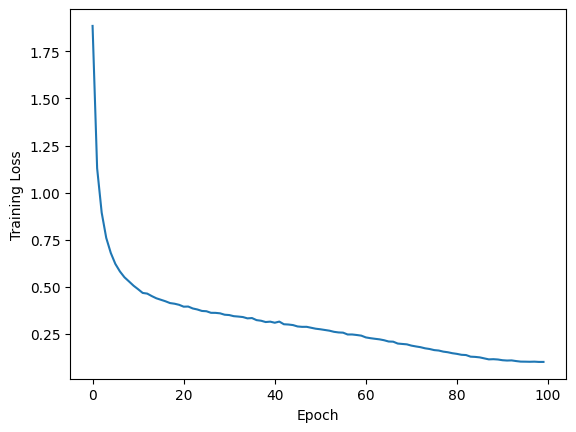

In [97]:
# Plot training loss
plt.plot(loss_log)
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.show()

In [98]:
# model.load_state_dict(torch.load("model.pt"))
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for inputs, labels in testloader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        outputs = inference(model, inputs)
        _, pred = outputs.max(1)
        total += labels.size(0)
        correct += pred.eq(labels).sum().item()

acc = 100 * correct / total
print(f"Test accuracy: {acc:.2f}%")

Test accuracy: 89.72%


In [99]:
from torchsummary import summary
summary(model, (3, 32, 32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 16, 32, 32]             432
       BatchNorm2d-2           [-1, 16, 32, 32]              32
              ReLU-3           [-1, 16, 32, 32]               0
            Conv2d-4           [-1, 16, 32, 32]           2,304
       BatchNorm2d-5           [-1, 16, 32, 32]              32
        ReLUConvBN-6           [-1, 16, 32, 32]               0
              ReLU-7           [-1, 16, 32, 32]               0
            Conv2d-8           [-1, 16, 32, 32]           2,304
       BatchNorm2d-9           [-1, 16, 32, 32]              32
       ReLUConvBN-10           [-1, 16, 32, 32]               0
             ReLU-11           [-1, 16, 32, 32]               0
           Conv2d-12           [-1, 16, 32, 32]           2,304
      BatchNorm2d-13           [-1, 16, 32, 32]              32
       ReLUConvBN-14           [-1, 16,

**Fill-in the Results:**
- Model Size: __ KB
- Test Accuracy: __ %

**Provide brief notes (architecture choice, training decisions):**

# 2.2 Inference using ONNXRuntime (CPU)

Export your model to ONNX and run inference using ONNXRuntime (CPU).



In [100]:
# Load full trained model
# model = get_cell_based_tiny_net(config).to(DEVICE)
# model.load_state_dict(torch.load("model_9369.pt", map_location=DEVICE))

# Dummy input for CIFAR-10
dummy_input = torch.randn(1, 3, 32, 32)

# Export to ONNX
model.to("cpu")  # ONNX export requires CPU model
torch.onnx.export(model, 
                  dummy_input, 
                  ONNX_PATH, 
                  opset_version=13, 
                  input_names=["input"],
                  output_names=["output"],
                  dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}},
                  verbose=False)

print("Saved:", ONNX_PATH)

Saved: model_5338.onnx


In [101]:
testloader = torch.utils.data.DataLoader(
    testset, batch_size=256, shuffle=False, num_workers=2
)

# ---- create ONNX runtime session ----
ort_sess = onnxruntime.InferenceSession(ONNX_PATH)

# ---- inference loop ----
correct = 0
total = 0

for images, labels in testloader:
    # Convert to numpy, channel-first
    images_np = images.numpy()
    
    # Run ONNX model
    outputs = ort_sess.run(None, {'input': images_np})
    logits = outputs[0]
    preds = np.argmax(logits, axis=1)
    correct += (preds == labels.numpy()).sum()
    total += labels.size(0)

print(f"Test Accuracy: {100 * correct / total:.2f}%")

Test Accuracy: 89.71%


**Fill-in the Results:**
- ONNX Model Size: __ KB
- Test Accuracy (ONNX): __ %
- Inference Time (FP32 Original): __ ms/batch
- Inference Time (ONNX FP32): __ ms/batch

**Provide brief comparison/analysis:**

# 2.3 Post Training Quantization (Static)
Perform INT8 static quantization. Target: < 5% accuracy drop from FP32.

In [102]:
# ---- calibration dataset (small subset of CIFAR10) ----
# transform = transforms.Compose([
#     transforms.ToTensor(),
#     transforms.Normalize((0.4914,0.4822,0.4465),
#                          (0.2023,0.1994,0.2010))
# ])

dataset = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=transform_train)

# ---- calibration reader ----
class CIFARReader(CalibrationDataReader):
    def __init__(self, dataset, input_name, num_samples=300):
        self.input_name = input_name
        self.data = []
        for i in range(num_samples):
            img, _ = dataset[i]
            self.data.append({input_name: img.unsqueeze(0).numpy()})
        self.enum = iter(self.data)

    def get_next(self):
        return next(self.enum, None)

# ---- find ONNX input name ----
model = onnx.load(ONNX_PATH)
input_name = model.graph.input[0].name

reader = CIFARReader(dataset, input_name)

# ---- run static quantization ----
quantize_static(
    model_input=ONNX_PATH,
    model_output="model_int8.onnx",
    calibration_data_reader=reader,
    weight_type=QuantType.QInt8
)

print("INT8 model saved: model_int8.onnx")

Files already downloaded and verified


INT8 model saved: model_int8.onnx


In [104]:
testloader = torch.utils.data.DataLoader(
    testset, batch_size=128, shuffle=False, num_workers=2
)

# ---- create ONNX runtime session ----
ort_sess = onnxruntime.InferenceSession("model_int8.onnx")

# ---- inference loop ----
correct = 0
total = 0

for images, labels in testloader:
    # Convert to numpy, channel-first
    images_np = images.numpy()
    
    # Run ONNX model
    outputs = ort_sess.run(None, {'input': images_np})
    logits = outputs[0]
    preds = np.argmax(logits, axis=1)
    correct += (preds == labels.numpy()).sum()
    total += labels.size(0)

print(f"Test Accuracy: {100 * correct / total:.2f}%")

Test Accuracy: 89.85%


**Fill-in the Results:**
- INT8 Model Size: __ KB
- INT8 Test Accuracy: __ %
- Accuracy Drop: __ %
- Inference Time (INT8): __ ms/batch

**Quantization settings used:**

# **OPTIONAL - BONUS** 2.4 Post Training Quantization (Dynamic)

*(Optional)* Perform INT8 dynamic quantization.


In [111]:
# Your code goes here (optional)
from onnxruntime.quantization import quantize_dynamic, QuantType

quantize_dynamic(
    model_input=ONNX_PATH,
    model_output="model_int8_dynamic.onnx",
    weight_type=QuantType.QUInt8
)

print("Dynamic INT8 model saved")

Dynamic INT8 model saved


In [112]:

# ---- create ONNX runtime session ----
ort_sess = onnxruntime.InferenceSession("model_int8_dynamic.onnx")

# ---- inference loop ----
correct = 0
total = 0

for images, labels in testloader:
    # Convert to numpy, channel-first
    images_np = images.numpy()
    
    # Run ONNX model
    outputs = ort_sess.run(None, {'input': images_np})
    logits = outputs[0]
    preds = np.argmax(logits, axis=1)
    correct += (preds == labels.numpy()).sum()
    total += labels.size(0)

print(f"Test Accuracy: {100 * correct / total:.2f}%")

Test Accuracy: 89.80%


**Results:**
- INT8 Model Size: __ KB
- INT8 Test Accuracy: __ %
- Accuracy Drop: __ %
- Inference Time (INT8): __ ms/batch

**Comparison with static quantization:**

# Summary Table

| Metric | FP32 (Original) | FP32 (ONNX) | INT8 Static | INT8 Dynamic (Optional) |
|--------|-----------------|-------------|-------------|--------------|
| Size (KB) | | | | |
| Accuracy (%) | | | | |
| Inference (ms) | | | | |